In [1]:
import matplotlib.pyplot as plt
from plots.mpltoolkit import named_colors, mpl_loc, fancy_legend, load_style_sheet
import numpy as np
import vice
import sys
import os
from databanks.SDSS.DR19 import ASPCAP_GIANTS as dr19giants
from databanks.SDSS.DR19.ages import roberts2025_cn_age
dr19giants["absz"] = [abs(z) for z in dr19giants["z"]]
dr19giants["c_n"] = [a - b for a, b in zip(dr19giants["c_h"], dr19giants["n_h"])]
dr19giants["age"] = [roberts2025_cn_age(cn, feh) for cn, feh in zip(
    dr19giants["c_n"], dr19giants["fe_h"])]
dr19giants = vice.dataframe(dr19giants)
load_style_sheet("papers")
print(sys.version_info[:])

/Users/jamesjohnson/Work/Research/lib/public-dev/VICE/vice/version.py:137: VersionWarning: Using an un-released version of VICE.
  if not self.isreleased: warnings.warn("""\


(3, 12, 3, 'final', 0)


In [5]:
# sub = dr19giants.filter(
#     "rgal", ">=", 7).filter(
#     "rgal", "<=", 9).filter(
#     "absz", "<=", 0.5)
feh_err = dr19giants["e_fe_h"]
mgh_err = dr19giants["e_mg_h"]
feh_err = list(filter(lambda x: not np.isnan(x), feh_err))
mgh_err = list(filter(lambda x: not np.isnan(x), mgh_err))
print(np.median(feh_err))
print(np.median(mgh_err))

0.010772
0.017079


/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_84861/3114868477.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


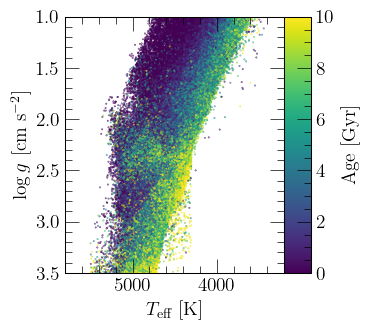

In [4]:
fig = plt.figure(figsize = (3.4, 3.4))
ax = fig.add_subplot(111)
ax.set_xlabel(r"$T_\text{eff}$ [K]")
ax.set_ylabel(r"$\log g$ [cm s$^{-2}$]")
ax.set_xlim([3200, 5800])
ax.set_ylim([1, 3.5])
ax.invert_xaxis()
ax.invert_yaxis()
cbar_ax = fig.add_axes([0.8, 0.8, 0.1, 0.8])

kwargs = {
    "c": dr19giants["age"],
    "cmap": plt.get_cmap("viridis"),
    "rasterized": True,
    "s": 0.1,
    "vmin": 0,
    "vmax": 10
}
sc = ax.scatter(dr19giants["teff"], dr19giants["logg"], **kwargs)

cbar = plt.colorbar(sc, cax = cbar_ax, orientation = "vertical")
cbar.set_label(r"Age [Gyr]")

plt.tight_layout()
plt.subplots_adjust(right = 0.85)
cbar_ax.set_position([
    ax.get_position().x1,
    ax.get_position().y0,
    0.08,
    ax.get_position().y1 - ax.get_position().y0
])
plt.show()

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_84861/2973777454.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


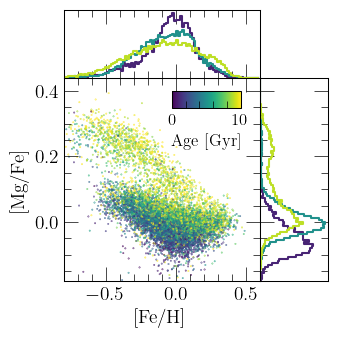

In [29]:
RMIN = 7
RMAX = 9
ABSZMIN = 0
ABSZMAX = 0.5
NSTARS = 10000
AGE_BINS = [[0, 2], [4, 6], [8, 10]]
COLORMAP = "viridis"
# CMAP = plt.get_cmap("viridis")

fig = plt.figure(figsize = (3.4, 3.4))
ax = fig.add_subplot(111)
ax.set_xlabel(r"[Fe/H]")
ax.set_ylabel(r"[Mg/Fe]")
ax.set_xlim([-0.8, 0.6])
ax.set_ylim([-0.18, 0.44])
top = fig.add_axes([0.1, 0.8, 0.8, 0.1], sharex = ax)
right = fig.add_axes([0.8, 0.1, 0.1, 0.8], sharey = ax)
top.tick_params(axis = 'y', which = "both", left = False, right = False)
right.tick_params(axis = 'x', which = "both", top = False, bottom = False)
for ax_ in [top, right]:
    plt.setp(ax_.get_xticklabels(), visible = False)
    plt.setp(ax_.get_yticklabels(), visible = False)

norm = plt.Normalize(vmin = 0, vmax = 10)
# sm = plt.cm.ScalarMappable(cmap = COLORMAP, norm = norm)
cmap = plt.get_cmap(COLORMAP)
cbar_ax = fig.add_axes([0.5, 0.5, 0.3, 0.1])
cbar_ax.tick_params(labelsize = 12)

sub = dr19giants.filter(
    "rgal", ">=", RMIN).filter(
    "rgal", "<=", RMAX).filter(
    "absz", ">=", ABSZMIN).filter(
    "absz", "<=", ABSZMAX)
indices = np.random.choice(len(sub["fe_h"]), size = NSTARS, replace = False)
age = [sub["age"][i] for i in indices]
mgh = [sub["mg_h"][i] for i in indices]
feh = [sub["fe_h"][i] for i in indices]
mgfe = [mg - fe for mg, fe in zip(mgh, feh)]
sm = ax.scatter(feh, mgfe,
    # c = cmap(norm(age)),
    c = age,
    rasterized = True,
    s = 0.1,
    vmin = 0,
    vmax = 10)
cbar = plt.colorbar(sm, cax = cbar_ax, orientation = "horizontal")
cbar.set_label(r"Age [Gyr]", fontsize = 12)

for i in range(len(AGE_BINS)):
    subsub = sub.filter(
        "age", ">=", AGE_BINS[i][0]).filter(
        "age", "<=", AGE_BINS[i][1])
    mgfe = [mg - fe for mg, fe in zip(subsub["mg_h"], subsub["fe_h"])]
    hist_kwargs = {
        "bins": 100,
        "density": True
    }
    step_kwargs = {
        "where": "post",
        "c": cmap(norm(sum(AGE_BINS[i]) / 2))
    }
    counts, bins = np.histogram(subsub["fe_h"], range = ax.get_xlim(), **hist_kwargs)
    top.step(bins[:-1], counts, **step_kwargs)
    counts, bins = np.histogram(mgfe, range = ax.get_ylim(), **hist_kwargs)
    right.step(counts, bins[:-1], **step_kwargs)

top.set_ylim([0, top.get_ylim()[1]])
right.set_xlim([0, right.get_xlim()[1]])

plt.tight_layout()
plt.subplots_adjust(right = 0.78, top = 0.78)
cbar_ax.set_position([
    0.55 * (ax.get_position().x1 - ax.get_position().x0) + ax.get_position().x0,
    0.85 * (ax.get_position().y1 - ax.get_position().y0) + ax.get_position().y0,
    0.35 * (ax.get_position().x1 - ax.get_position().x0),
    0.05
])
top.set_position([
    ax.get_position().x0,
    ax.get_position().y1,
    ax.get_position().x1 - ax.get_position().x0,
    0.2
])
right.set_position([
    ax.get_position().x1,
    ax.get_position().y0,
    0.2,
    ax.get_position().y1 - ax.get_position().y0
])
plt.show()

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_84861/1653370908.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


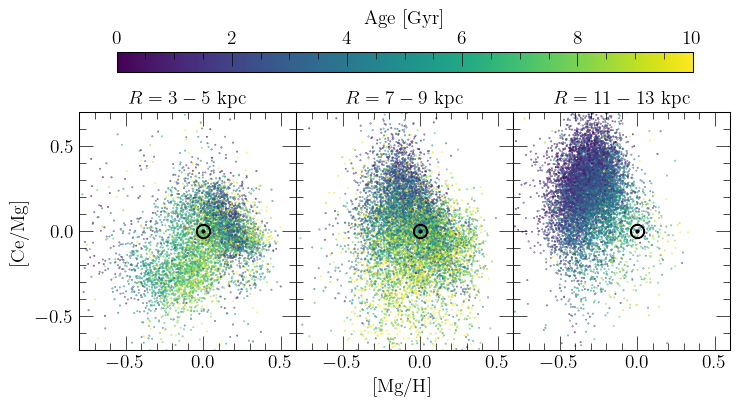

In [46]:
RADII = [[3, 5], [7, 9], [11, 13]]
COLORMAP = "viridis"

fig = plt.figure(figsize = (7.5, 4))
axes = []
for i in range(len(RADII)):
    kwargs = {}
    if i:
        kwargs["sharex"] = axes[0]
        kwargs["sharey"] = axes[0]
    else: pass
    axes.append(fig.add_subplot(101 + 10 * len(RADII) + i, **kwargs))
    if i: plt.setp(axes[i].get_yticklabels(), visible = False)
    axes[i].set_title(r"$R = %d - %d$ kpc" % (RADII[i][0], RADII[i][1]))
axes[0].set_xlim([-0.8, 0.6])
axes[0].set_ylim([-0.7, 0.7])
axes[0].set_yticks([-0.5, 0, 0.5])
axes[1].set_xlabel(r"[Mg/H]")
axes[0].set_ylabel(r"[Ce/Mg]")

def plot_stars(ax, sample, rmin = 7, rmax = 9, abszmin = 0, abszmax = 0.5, N = 10000, **kwargs):
    sub = sample.filter(
        "rgal", ">=", rmin).filter(
        "rgal", "<=", rmax).filter(
        "absz", ">=", abszmin).filter(
        "absz", "<=", abszmax)
    ce_mg = [ce - mg for ce, mg in zip(sub["ce_h"], sub["mg_h"])]
    indices = np.random.choice(len(ce_mg), size = N, replace = False)
    ce_mg = [ce_mg[i] for i in indices]
    mgh = [sub["mg_h"][i] for i in indices]
    age = [sub["age"][i] for i in indices]
    return ax.scatter(mgh, ce_mg, c = age, vmin = 0, vmax = 10, **kwargs)

for i in range(len(RADII)):
    kwargs = {
        "s": 0.1,
        "rasterized": True
    }
    sc = plot_stars(axes[i], dr19giants, rmin = RADII[i][0], rmax = RADII[i][1], **kwargs)
    axes[i].scatter([0], [0], marker = r"$\odot$", s = 100, color = named_colors()["black"])

cbar_ax = fig.add_axes([0.2, 0.8, 0.8, 0.1])
cbar = plt.colorbar(sc, cax = cbar_ax, orientation = "horizontal", location = "top")
cbar.set_label(r"Age [Gyr]")

plt.tight_layout()
plt.subplots_adjust(wspace = 0, top = 0.75)
cbar_ax.set_position([
    axes[0].get_position().x0 + 0.05,
    axes[0].get_position().y1 + 0.1,
    axes[-1].get_position().x1 - axes[0].get_position().x0 - 0.1,
    0.05
])
plt.show()

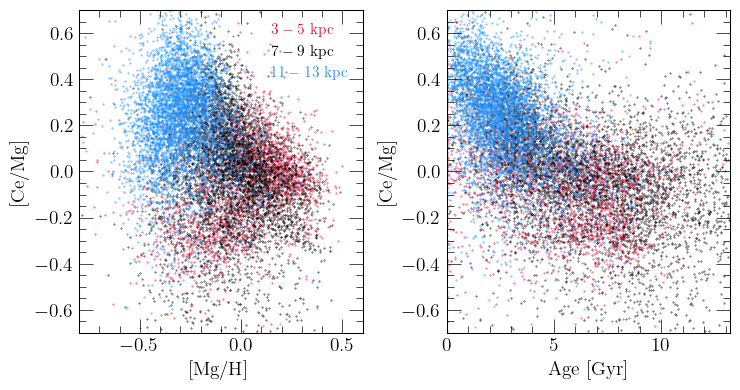

In [21]:
RADII = [[3, 5], [7, 9], [11, 13]]
COLORS = ["crimson", "black", "dodgerblue"]

fig = plt.figure(figsize = (7.5, 4))
axes = []
for i in range(2):
    kwargs = {}
    if i: kwargs["sharey"] = axes[0]
    axes.append(fig.add_subplot(121 + i, **kwargs))
axes[0].set_xlabel(r"[Mg/H]")
axes[0].set_ylabel(r"[Ce/Mg]")
axes[1].set_xlabel(r"Age [Gyr]")
axes[1].set_ylabel(r"[Ce/Mg]")
axes[0].set_xlim([-0.8, 0.6])
axes[0].set_ylim([-0.7, 0.7])
axes[1].set_xlim([0, 13.2])
axes[1].set_ylim([-0.7, 0.7])

def plot_relations(ax_mgh, ax_age, sample, rmin = 7, rmax = 9, abszmin = 0, abszmax = 0.5, N = 5000, **kwargs):
    sub = sample.filter(
        "rgal", ">=", rmin).filter(
        "rgal", "<=", rmax).filter(
        "absz", ">=", abszmin).filter(
        "absz", "<=", abszmax)
    ce_mg = [ce - mg for ce, mg in zip(sub["ce_h"], sub["mg_h"])]
    indices = np.random.choice(len(ce_mg), size = N, replace = False)
    mgh = [sub["mg_h"][i] for i in indices]
    ce_mg = [ce_mg[i] for i in indices]
    age = [sub["age"][i] for i in indices]
    ax_mgh.scatter(mgh, ce_mg, **kwargs)
    ax_age.scatter(age, ce_mg, **kwargs)

for i in range(len(RADII)):
    kwargs = {
        "c": named_colors()[COLORS[i]],
        "s": 0.1,
        "rasterized": True
    }
    plot_relations(*axes, dr19giants, rmin = RADII[i][0], rmax = RADII[i][1], **kwargs)

lines = []
for i in range(len(RADII)):
    kwargs = {
        "c": named_colors()[COLORS[i]],
        "label": r"$%d- %d$ kpc" % (RADII[i][0], RADII[i][1])
    }
    lines.append(axes[0].plot([1, 2], [1, 2], **kwargs)[0])
kwargs = {
    "loc": mpl_loc("upper right"),
    "ncol": 1,
    "handlelength": 0,
    "fontsize": 11
}
leg = axes[0].legend(**kwargs)
fancy_legend(leg, COLORS)
for i in range(len(lines)): lines[i].remove()

plt.tight_layout()
plt.show()